In [102]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from tqdm import tqdm
import os
import polars as pl
from towbintools.foundation.file_handling import get_dir_filemap, add_dir_to_experiment_filemap, read_filemap
from joblib import Parallel, delayed
import bottleneck as bn

In [103]:
# change figure size to your liking
plt.rcParams['figure.figsize'] = [12, 10]

# make lines thicker
plt.rcParams['lines.linewidth'] = 3

# make font size bigger
plt.rcParams.update({'font.size': 28})

plt.rcParams['figure.constrained_layout.use'] = True

# ensure fonts are saved as text in svg files
plt.rcParams['svg.fonttype'] = 'none'

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

plt.rcParams.update({
    "pgf.preamble": r"\usepackage{arev}\n\usepackage[T1]{fontenc}"
})

ylim = (0.75, 1.4)

In [104]:
experiment_dir = "/mnt/towbin.data/shared/spsalmon/20251023_115945_091_ZIVA_60x_397_405_yap_dynamics"
output_dir = "./plots/20251023_115945_091_ZIVA_60x_397_405_yap_dynamics/"
os.makedirs(output_dir, exist_ok=True)
raw_dir = os.path.join(experiment_dir, "raw_stacks")
raw_dir_name = os.path.basename(raw_dir)
analysis_dir = os.path.join(experiment_dir, "analysis_stacks")
report_dir = os.path.join(analysis_dir, "report")

stacks_filemap = get_dir_filemap(raw_dir)
stacks_filemap = stacks_filemap.rename({"ImagePath": raw_dir_name})
mask_dir = os.path.join(analysis_dir, "ch2_seg_cellpose")
stacks_filemap = add_dir_to_experiment_filemap(stacks_filemap, mask_dir, os.path.basename(mask_dir))

classification_dir = None
measurements_dir = os.path.join(analysis_dir, "ch1_cellpose_final_measurements")
stacks_filemap = add_dir_to_experiment_filemap(stacks_filemap, measurements_dir, os.path.basename(measurements_dir))

stacks_filemap = stacks_filemap.filter((pl.col(os.path.basename(mask_dir)) != "") & (pl.col(os.path.basename(measurements_dir)) != ""))

In [105]:
experiment_filemap_path = os.path.join(experiment_dir, "analysis", "report", "analysis_filemap_annotated.csv")
experiment_filemap = read_filemap(experiment_filemap_path)
experiment_filemap = experiment_filemap.join(stacks_filemap, on=['Time', 'Point'], how='left')
# remove all the columns with "_at" in their name, as these are not needed for the plotting
experiment_filemap = experiment_filemap.drop([col for col in experiment_filemap.columns if "_at" in col])
# experiment_filemap = experiment_filemap.filter(pl.col("ch1_cellpose_measurements").is_not_null())

experiment_filemap = experiment_filemap.with_columns((pl.col("ExperimentTime") / 3600).alias("ExperimentTimeHours"))

In [106]:
import yaml

def build_conditions(conditions_yaml):
    """
    Process a conditions YAML file structured in a factorized way. Refer to the documentation for the expected format.
    The function will return a list of dictionaries, each representing a condition with its parameters.

    Parameters:
        conditions_yaml (str or dict): Path to the YAML file or a dictionary containing the conditions.
    Returns:
        list: A list of dictionaries, each representing a condition with its parameters.
    Raises:
        ValueError: If the conditions YAML file is not structured correctly.
    """
    if isinstance(conditions_yaml, str):
        with open(conditions_yaml) as file:
            conditions_dict = yaml.safe_load(file)
            file.close()
    elif isinstance(conditions_yaml, dict):
        conditions_dict = conditions_yaml

    conditions = []
    condition_id = 0

    for condition in conditions_dict["conditions"]:
        condition = {
            key: [val] if not isinstance(val, list) else val
            for key, val in condition.items()
        }

        lengths = {len(val) for val in condition.values()}
        if len(lengths) > 2 or (len(lengths) == 2 and 1 not in lengths):
            raise ValueError(
                "All lists in the condition must have the same length or be of length 1."
            )

        max_length = max(lengths)
        for i in range(max_length):
            condition_dict = {
                key: val[0] if len(val) == 1 else val[i]
                for key, val in condition.items()
            }
            condition_dict["condition_id"] = condition_id
            conditions.append(condition_dict)
            condition_id += 1

    return conditions


def _add_conditions_to_filemap(experiment_filemap, conditions):
    """Add conditions to experiment filemap based on point ranges or pad values."""
    if "Pad" in experiment_filemap.columns:
        new_columns = experiment_filemap.select(pl.col("Point"), pl.col("Pad"))
    else:
        new_columns = experiment_filemap.select(pl.col("Point"))
    for condition in conditions:
        # Get condition rows mask
        if "point_range" in condition:
            point_range = condition["point_range"]
            # handle both single range and list of ranges
            if isinstance(point_range[0], list):
                # multiple point ranges - build expressions list
                mask_exprs = [
                    (pl.col("Point") >= pr[0]) & (pl.col("Point") <= pr[1])
                    for pr in point_range
                ]
                # Combine with or operator
                condition_mask = mask_exprs[0]
                for expr in mask_exprs[1:]:
                    condition_mask = condition_mask | expr
            else:
                # single point range
                condition_mask = (pl.col("Point") >= point_range[0]) & (
                    pl.col("Point") <= point_range[1]
                )
            filter_key = "point_range"
        elif "pad" in condition:
            pad = condition["pad"]
            condition_mask = pl.col("Pad") == pad
            filter_key = "pad"
        else:
            print(
                "Condition does not contain 'point_range' or 'pad' key, impossible to add condition to filemap, skipping."
            )
            continue

        # Extract the condition attributes to add (excluding the filter key)
        conditions_to_add = {k: v for k, v in condition.items() if k != filter_key}

        column_ops = []
        for key, val in conditions_to_add.items():
            # For new columns, add with null values first if needed
            if key not in new_columns.columns:
                new_columns = new_columns.with_columns(pl.lit(None).alias(key))

            # Build the column operation but don't apply it yet
            column_ops.append(
                pl.when(condition_mask)
                .then(pl.lit(val))
                .otherwise(pl.col(key))
                .alias(key)
            )

        # Add the new columns to the DataFrame
        if column_ops:
            new_columns = new_columns.with_columns(column_ops)

    if "Pad" in new_columns.columns:
        new_columns = new_columns.drop(["Point", "Pad"])
    else:
        new_columns = new_columns.drop(["Point"])

    # Apply the new columns to the experiment filemap
    if not new_columns.is_empty():
        experiment_filemap = experiment_filemap.with_columns(new_columns)

    return experiment_filemap

In [107]:
condition_id_to_color = {
    0: "#4497E0",
    1: "#124877",
}

new_descriptions = {
    0: "control",
    1: "epidermal growth inhibition",
}

In [108]:
condition_file = os.path.join(experiment_dir, "doc", "conditions.yaml")
conditions = build_conditions(condition_file)
experiment_filemap = _add_conditions_to_filemap(experiment_filemap, conditions)
experiment_filemap

Time,Point,raw,ExperimentTime,analysis/ch1_seg,ch1_seg_area,placeholder_worm_type,HatchTime,M1,M2,M3,M4,Ignore,raw_stacks,ch2_seg_cellpose,ch1_cellpose_final_measurements,ExperimentTimeHours,auxin_concentration,strain,description,condition_id
i64,i64,str,f64,str,f64,str,f64,f64,f64,f64,str,bool,str,str,str,f64,i32,str,str,i32
0,0,"""/mnt/towbin.data/shared/spsalm…",0.0,"""/mnt/towbin.data/shared/spsalm…",1670.94884,"""worm""",null,null,null,null,null,true,null,null,null,0.0,1000,"""wBT397""","""col-10:TIR, raga-1:AID, 1mM IA…",1
1,0,"""/mnt/towbin.data/shared/spsalm…",1199.0,"""/mnt/towbin.data/shared/spsalm…",2079.862349,"""worm""",null,null,null,null,null,true,null,null,null,0.333056,1000,"""wBT397""","""col-10:TIR, raga-1:AID, 1mM IA…",1
2,0,"""/mnt/towbin.data/shared/spsalm…",2399.0,"""/mnt/towbin.data/shared/spsalm…",1877.889824,"""worm""",null,null,null,null,null,true,null,null,null,0.666389,1000,"""wBT397""","""col-10:TIR, raga-1:AID, 1mM IA…",1
3,0,"""/mnt/towbin.data/shared/spsalm…",3602.0,"""/mnt/towbin.data/shared/spsalm…",2371.829594,"""worm""",null,null,null,null,null,true,null,null,null,1.000556,1000,"""wBT397""","""col-10:TIR, raga-1:AID, 1mM IA…",1
4,0,"""/mnt/towbin.data/shared/spsalm…",4799.0,"""/mnt/towbin.data/shared/spsalm…",2361.048977,"""worm""",null,null,null,null,null,true,null,null,null,1.333056,1000,"""wBT397""","""col-10:TIR, raga-1:AID, 1mM IA…",1
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
211,59,"""/mnt/towbin.data/shared/spsalm…",253046.0,"""/mnt/towbin.data/shared/spsalm…",1.0311895,"""worm""",10.0,57.0,null,null,null,true,null,null,null,70.290556,1000,"""wBT405""","""raga-1:AID, 1mM IAA""",0
212,59,"""/mnt/towbin.data/shared/spsalm…",254246.0,"""/mnt/towbin.data/shared/spsalm…",0.796828,"""worm""",10.0,57.0,null,null,null,true,null,null,null,70.623889,1000,"""wBT405""","""raga-1:AID, 1mM IAA""",0
213,59,"""/mnt/towbin.data/shared/spsalm…",255597.0,"""/mnt/towbin.data/shared/spsalm…",0.609339,"""worm""",10.0,57.0,null,null,null,true,null,null,null,70.999167,1000,"""wBT405""","""raga-1:AID, 1mM IAA""",0


In [109]:
def get_nuclear_stats_per_type(experiment_filemap, channel="ch1", types_to_ignore=['background']):
    rows = []
    def process_row(row, channel):
        measurements_path = row[f"{channel}_cellpose_final_measurements"]
        if measurements_path is None or not os.path.exists(measurements_path):
            return row
        try:
            measurements_df = pl.read_csv(measurements_path)
        except Exception as e:
            return row
    
        # for each unique nucleus type, compute the mean and std of the measurements
        for nucleus_type in measurements_df["Type"].unique():
            if nucleus_type in types_to_ignore:
                continue
            nucleus_type_df = measurements_df.filter(pl.col("Type") == nucleus_type)
            for col in nucleus_type_df.columns:
                if col not in ["Type", "Label", "Z"]:
                    mean_col_name = f"{col}_mean_{nucleus_type}"
                    std_col_name = f"{col}_std_{nucleus_type}"
                    row[mean_col_name] = bn.nanmean(nucleus_type_df[col].to_numpy())
                    row[std_col_name] = bn.nanstd(nucleus_type_df[col].to_numpy())
        return row
    
    rows = Parallel(n_jobs=-1)(
        delayed(process_row)(row, channel) 
        for row in tqdm(experiment_filemap.iter_rows(named=True), total=experiment_filemap.height)
    )
    return pl.DataFrame(rows, infer_schema_length=10000)

experiment_filemap = get_nuclear_stats_per_type(experiment_filemap, channel="ch1")

100%|██████████| 12960/12960 [00:32<00:00, 396.92it/s]


In [110]:
experiment_filemap

Time,Point,raw,ExperimentTime,analysis/ch1_seg,ch1_seg_area,placeholder_worm_type,HatchTime,M1,M2,M3,M4,Ignore,raw_stacks,ch2_seg_cellpose,ch1_cellpose_final_measurements,ExperimentTimeHours,auxin_concentration,strain,description,condition_id,Size_mean_other,Size_std_other,MeanIntensityNucleus_mean_other,MeanIntensityNucleus_std_other,MedianIntensityNucleus_mean_other,MedianIntensityNucleus_std_other,MeanIntensityCytoplasm_mean_other,MeanIntensityCytoplasm_std_other,MedianIntensityCytoplasm_mean_other,MedianIntensityCytoplasm_std_other,NucleusCytoplasmRatioMean_mean_other,NucleusCytoplasmRatioMean_std_other,NucleusCytoplasmRatioMedian_mean_other,NucleusCytoplasmRatioMedian_std_other,Size_mean_epidermis,Size_std_epidermis,MeanIntensityNucleus_mean_epidermis,MeanIntensityNucleus_std_epidermis,MedianIntensityNucleus_mean_epidermis,MedianIntensityNucleus_std_epidermis,MeanIntensityCytoplasm_mean_epidermis,MeanIntensityCytoplasm_std_epidermis,MedianIntensityCytoplasm_mean_epidermis,MedianIntensityCytoplasm_std_epidermis,NucleusCytoplasmRatioMean_mean_epidermis,NucleusCytoplasmRatioMean_std_epidermis,NucleusCytoplasmRatioMedian_mean_epidermis,NucleusCytoplasmRatioMedian_std_epidermis,Size_mean_intestine,Size_std_intestine,MeanIntensityNucleus_mean_intestine,MeanIntensityNucleus_std_intestine,MedianIntensityNucleus_mean_intestine,MedianIntensityNucleus_std_intestine,MeanIntensityCytoplasm_mean_intestine,MeanIntensityCytoplasm_std_intestine,MedianIntensityCytoplasm_mean_intestine,MedianIntensityCytoplasm_std_intestine,NucleusCytoplasmRatioMean_mean_intestine,NucleusCytoplasmRatioMean_std_intestine,NucleusCytoplasmRatioMedian_mean_intestine,NucleusCytoplasmRatioMedian_std_intestine
i64,i64,str,f64,str,f64,str,f64,f64,f64,f64,null,bool,str,str,str,f64,i64,str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,0,"""/mnt/towbin.data/shared/spsalm…",0.0,"""/mnt/towbin.data/shared/spsalm…",1670.94884,"""worm""",null,null,null,null,null,true,null,null,null,0.0,1000,"""wBT397""","""col-10:TIR, raga-1:AID, 1mM IA…",1,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
1,0,"""/mnt/towbin.data/shared/spsalm…",1199.0,"""/mnt/towbin.data/shared/spsalm…",2079.862349,"""worm""",null,null,null,null,null,true,null,null,null,0.333056,1000,"""wBT397""","""col-10:TIR, raga-1:AID, 1mM IA…",1,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
2,0,"""/mnt/towbin.data/shared/spsalm…",2399.0,"""/mnt/towbin.data/shared/spsalm…",1877.889824,"""worm""",null,null,null,null,null,true,null,null,null,0.666389,1000,"""wBT397""","""col-10:TIR, raga-1:AID, 1mM IA…",1,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
3,0,"""/mnt/towbin.data/shared/spsalm…",3602.0,"""/mnt/towbin.data/shared/spsalm…",2371.829594,"""worm""",null,null,null,null,null,true,null,null,null,1.000556,1000,"""wBT397""","""col-10:TIR, raga-1:AID, 1mM IA…",1,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
4,0,"""/mnt/towbin.data/shared/spsalm…",4799.0,"""/mnt/towbin.data/shared/spsalm…",2361.048977,"""worm""",null,null,null,null,null,true,null,null,null,1.333056,1000,"""wBT397""","""col-10:TIR, raga-1:AID, 1mM IA…",1,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,nul

# Binned plots

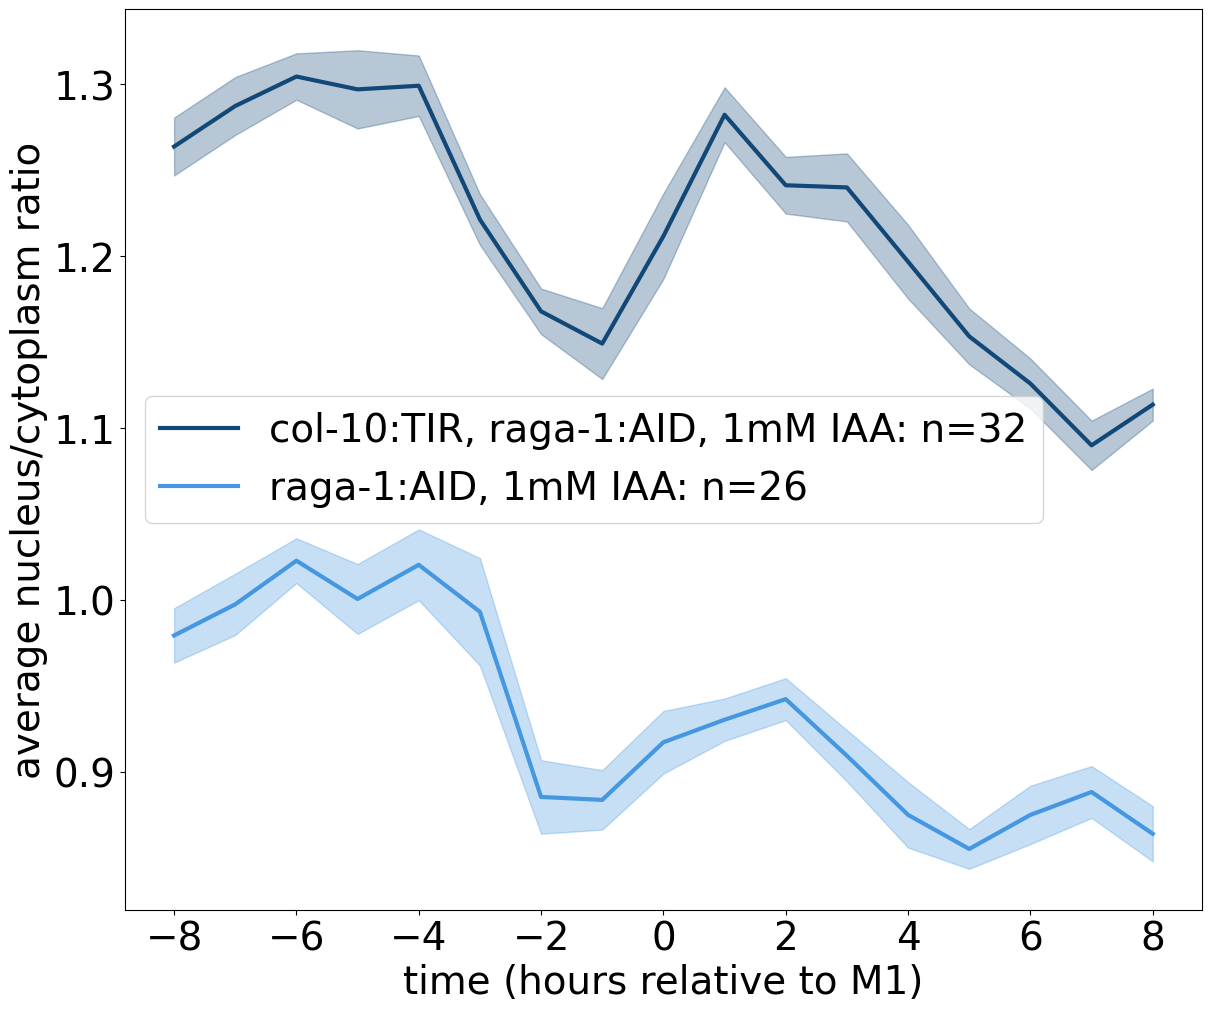

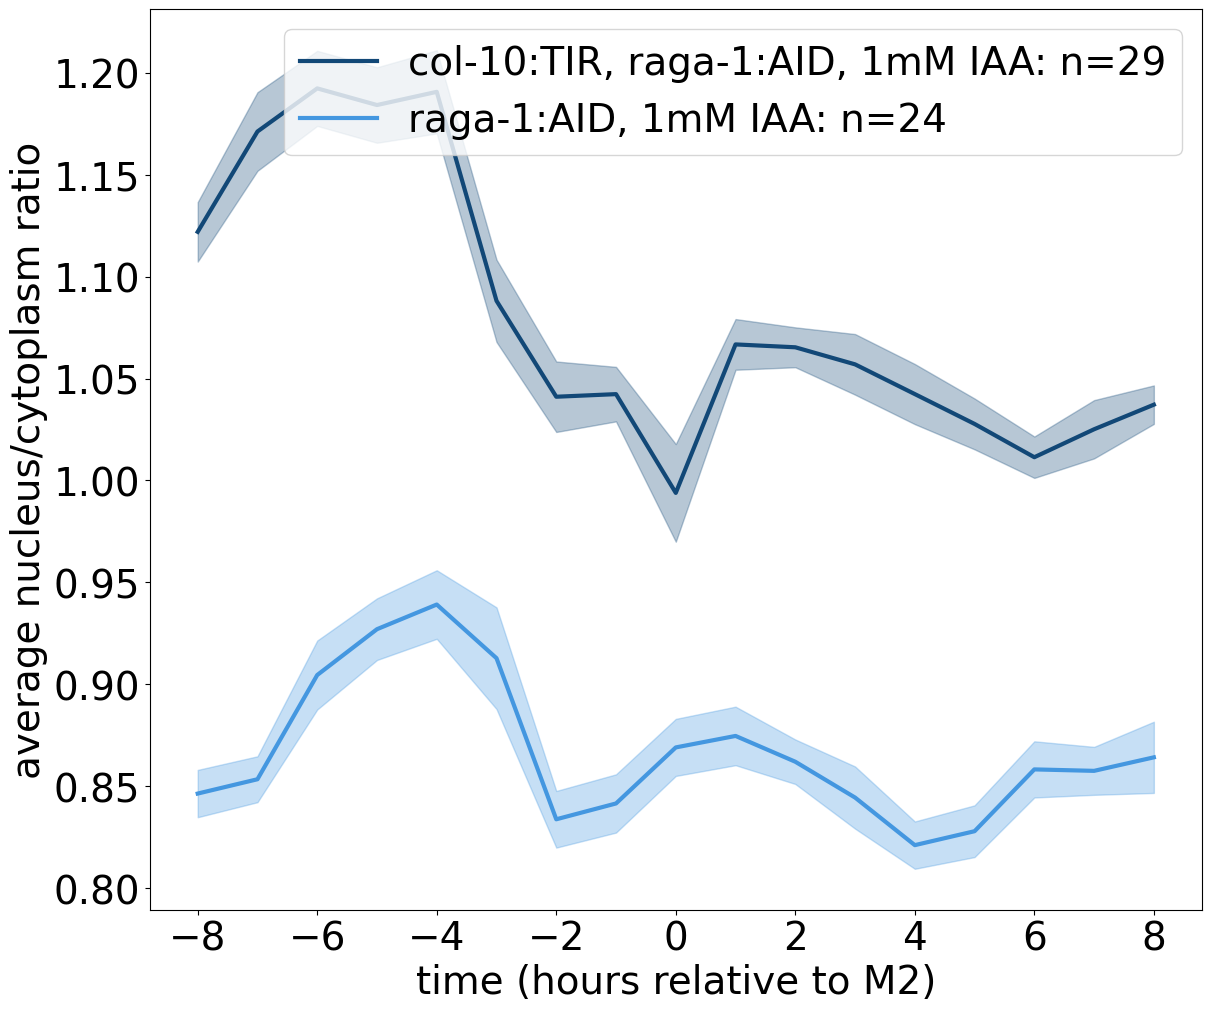

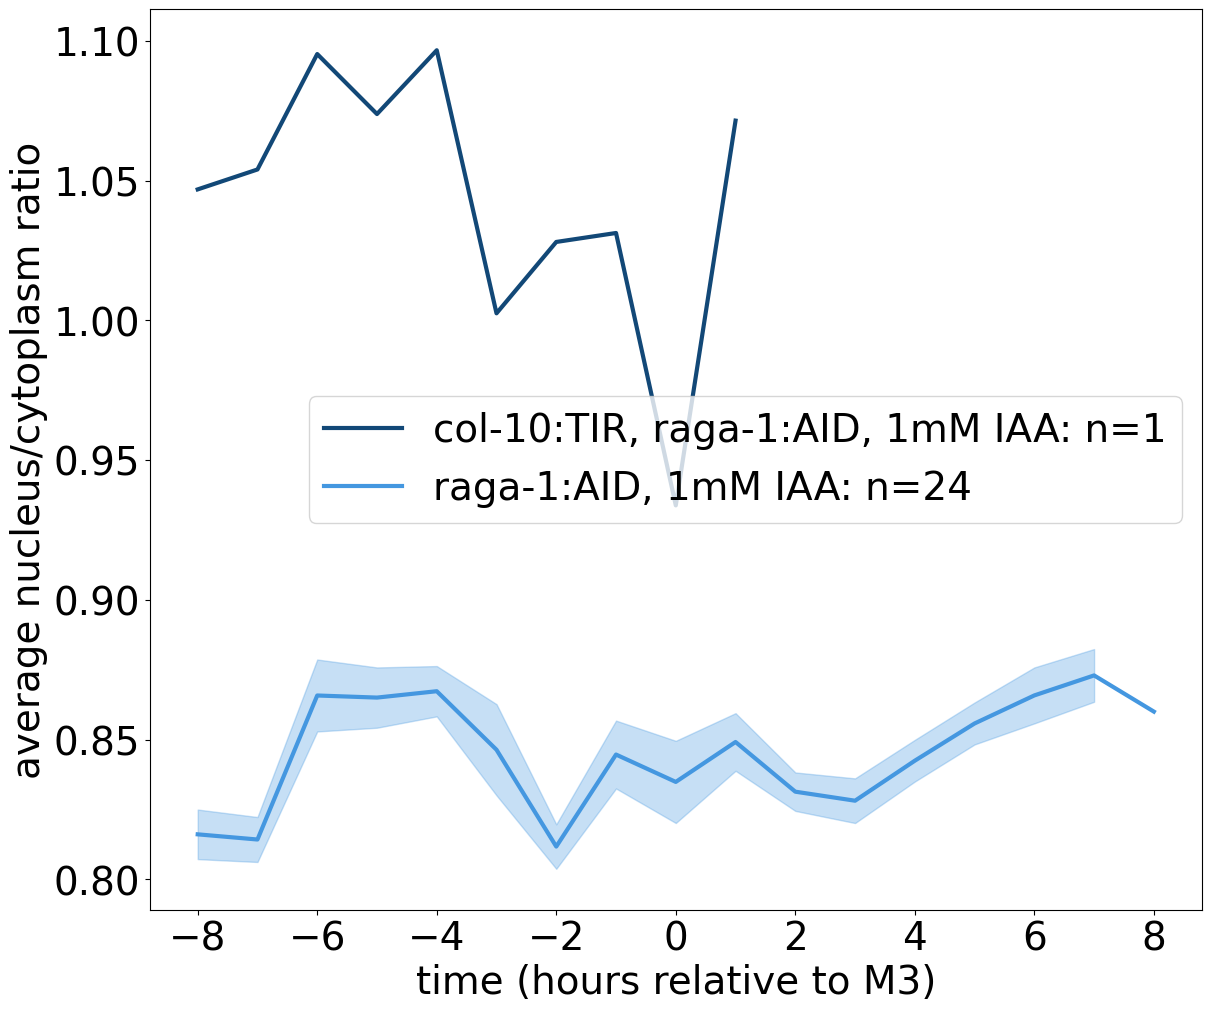

/tmp/ipykernel_14534/3460723476.py:78: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


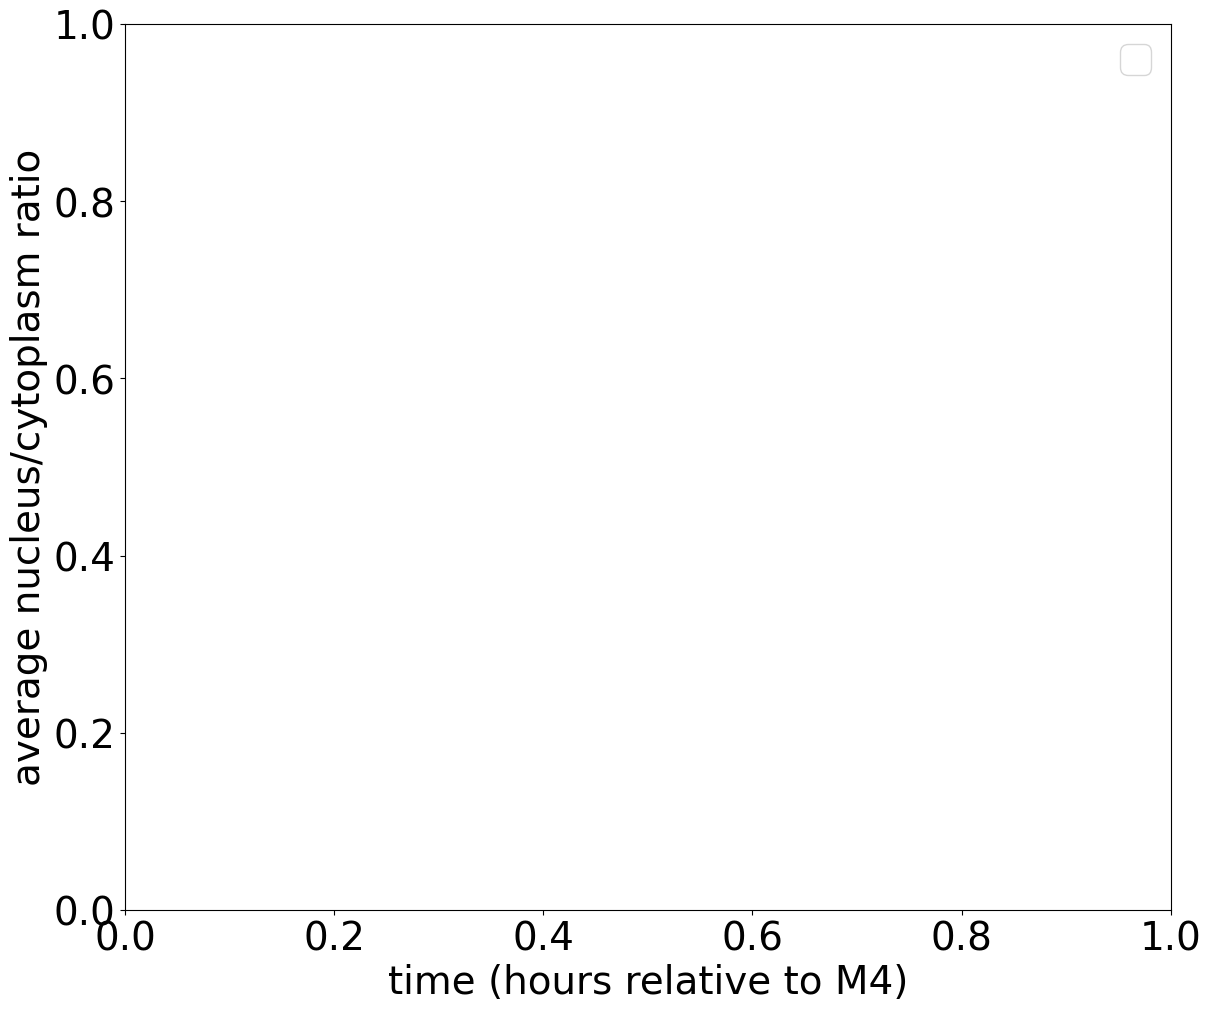

In [111]:
molts = ['M1', 'M2', 'M3', 'M4']
column_to_plot = "NucleusCytoplasmRatioMedian_mean_epidermis"


color_palette = plt.get_cmap("tab10")


for molt in molts:
    
    modified_point_filemaps = []
    for point_filemap in experiment_filemap.partition_by("Point", maintain_order=True):
        molt_time = point_filemap[molt][0]

        if molt_time is None:
            modified_point_filemaps.append(point_filemap.with_columns(
                pl.lit(np.nan).alias(f"ExperimentTimeHoursRelativeTo{molt}")
            ))

        else:
            molt_time = float(molt_time)
            point = point_filemap["Point"][0]

            molt_experiment_time = (
                point_filemap
                .filter(pl.col("Time") == molt_time)
                .select("ExperimentTimeHours")
                .item()
            )
            modified_point_filemaps.append(
                point_filemap.with_columns(
                    (pl.col("ExperimentTimeHours") - molt_experiment_time).alias(f"ExperimentTimeHoursRelativeTo{molt}")
                )
            )

    experiment_filemap = pl.concat(modified_point_filemaps).sort(["Point", "Time"])

    filemap_for_plotting = experiment_filemap.filter((pl.col(f"ExperimentTimeHoursRelativeTo{molt}") >= -8) & (pl.col(f"ExperimentTimeHoursRelativeTo{molt}") <= 8))

    filemap_for_plotting = filemap_for_plotting.with_columns(
        (pl.col(f"ExperimentTimeHoursRelativeTo{molt}") // 1).alias(f"ExperimentTimeHoursRelativeTo{molt}Bin")
    )
    # remove all the rows with null values in the column to plot
    filemap_for_plotting = filemap_for_plotting.filter(pl.col(f"ExperimentTimeHoursRelativeTo{molt}Bin").is_not_null())
    filemap_for_plotting = filemap_for_plotting.filter(pl.col(column_to_plot).is_not_null())
    conditions_filemaps = filemap_for_plotting.partition_by("condition_id", maintain_order=True)

    for i, condition_filemap in enumerate(conditions_filemaps):
        condition_id = condition_filemap["condition_id"][0]
        description = condition_filemap["description"][0]
        n_points = condition_filemap.select(pl.col("Point").n_unique()).item()
        mean_values = (
            condition_filemap
            .group_by(f"ExperimentTimeHoursRelativeTo{molt}Bin")
            .agg(pl.mean(column_to_plot).alias(column_to_plot))
            .sort(f"ExperimentTimeHoursRelativeTo{molt}Bin")
        )
        std_values = (
            condition_filemap        
            .group_by(f"ExperimentTimeHoursRelativeTo{molt}Bin")
            .agg(pl.std(column_to_plot).alias(column_to_plot))
            .sort(f"ExperimentTimeHoursRelativeTo{molt}Bin")
        )

        ste_values = std_values.with_columns(
            (pl.col(column_to_plot) / np.sqrt(n_points)).alias("ste")
        )
        plt.plot(mean_values[f"ExperimentTimeHoursRelativeTo{molt}Bin"], mean_values[column_to_plot], color = condition_id_to_color[condition_id], label=f"{description}: n={n_points}")
        plt.fill_between(
            mean_values[f"ExperimentTimeHoursRelativeTo{molt}Bin"],
            mean_values[column_to_plot] - 1.96 * ste_values["ste"],
            mean_values[column_to_plot] + 1.96 * ste_values["ste"],
            alpha=0.3,
            color = condition_id_to_color[condition_id]
        )

    plt.xlabel(f'time (hours relative to {molt})')
    plt.ylabel('average nucleus/cytoplasm ratio')
    plt.legend()
    plt.savefig(os.path.join(output_dir, f"{column_to_plot}_relative_to_{molt}.pdf"))
    plt.show()


# Rescaled plots

In [112]:
def separate_column_by_point(filemap, column):
    points = (
        filemap.select(pl.col("Point").unique(maintain_order=True).sort())
        .to_numpy()
        .flatten()
    )

    filemap_points = filemap.select(pl.col("Point"), pl.col(column))
    point_dataframes = filemap_points.partition_by("Point", maintain_order=True)

    sample = point_dataframes[0].select(pl.col(column)).head(1).item()
    is_string = isinstance(sample, str) or (
        hasattr(sample, "dtype") and np.issubdtype(sample.dtype, np.str_)
    )

    max_height = max(point_df.height for point_df in point_dataframes)
    if is_string:
        result = np.full((len(points), max_height), "error", dtype=object)
    else:
        result = np.full((len(points), max_height), np.nan)

    for i, point_df in enumerate(point_dataframes):
        point_column = point_df.select(pl.col(column)).to_numpy().squeeze()
        result[i, : len(point_column)] = point_column
    return result

def _get_time_ecdysis_and_durations(filemap):
    all_ecdysis_time_step = []
    all_ecdysis_index = []
    all_durations_time_step = []

    all_ecdysis_experiment_time = []
    all_durations_experiment_time = []

    ecdysis_columns = ["HatchTime", "M1", "M2", "M3", "M4"]
    column_list = ["Point", "Time", "ExperimentTime"] + ecdysis_columns
    filemap = filemap.select(pl.col(column_list))

    ecdysis_values = (
        filemap.group_by("Point", maintain_order=True)
        .agg(pl.col(ecdysis_columns).first())
        .drop("Point")
        .cast(pl.Float64)
    )

    time = separate_column_by_point(filemap, "Time").astype(float)
    experiment_time = separate_column_by_point(filemap, "ExperimentTime").astype(float)

    for i in range(len(ecdysis_values)):
        ecdysis = ecdysis_values[i].to_numpy().squeeze()
        time_of_point = time[i]
        experiment_time_of_point = experiment_time[i]

        ecdysis_index = [
            float(np.where(time_of_point == ecdysis)[0][0])
            if ecdysis in time_of_point
            else np.nan
            for ecdysis in ecdysis
        ]
        ecdysis_experiment_time = [
            experiment_time_of_point[int(index)] if not np.isnan(index) else np.nan
            for index in ecdysis_index
        ]
        all_ecdysis_time_step.append(ecdysis)
        all_ecdysis_index.append(ecdysis_index)
        all_ecdysis_experiment_time.append(ecdysis_experiment_time)

    return (
        time,
        experiment_time,
        np.array(all_ecdysis_index),
        np.array(all_ecdysis_time_step),
        np.array(all_ecdysis_experiment_time),
    )

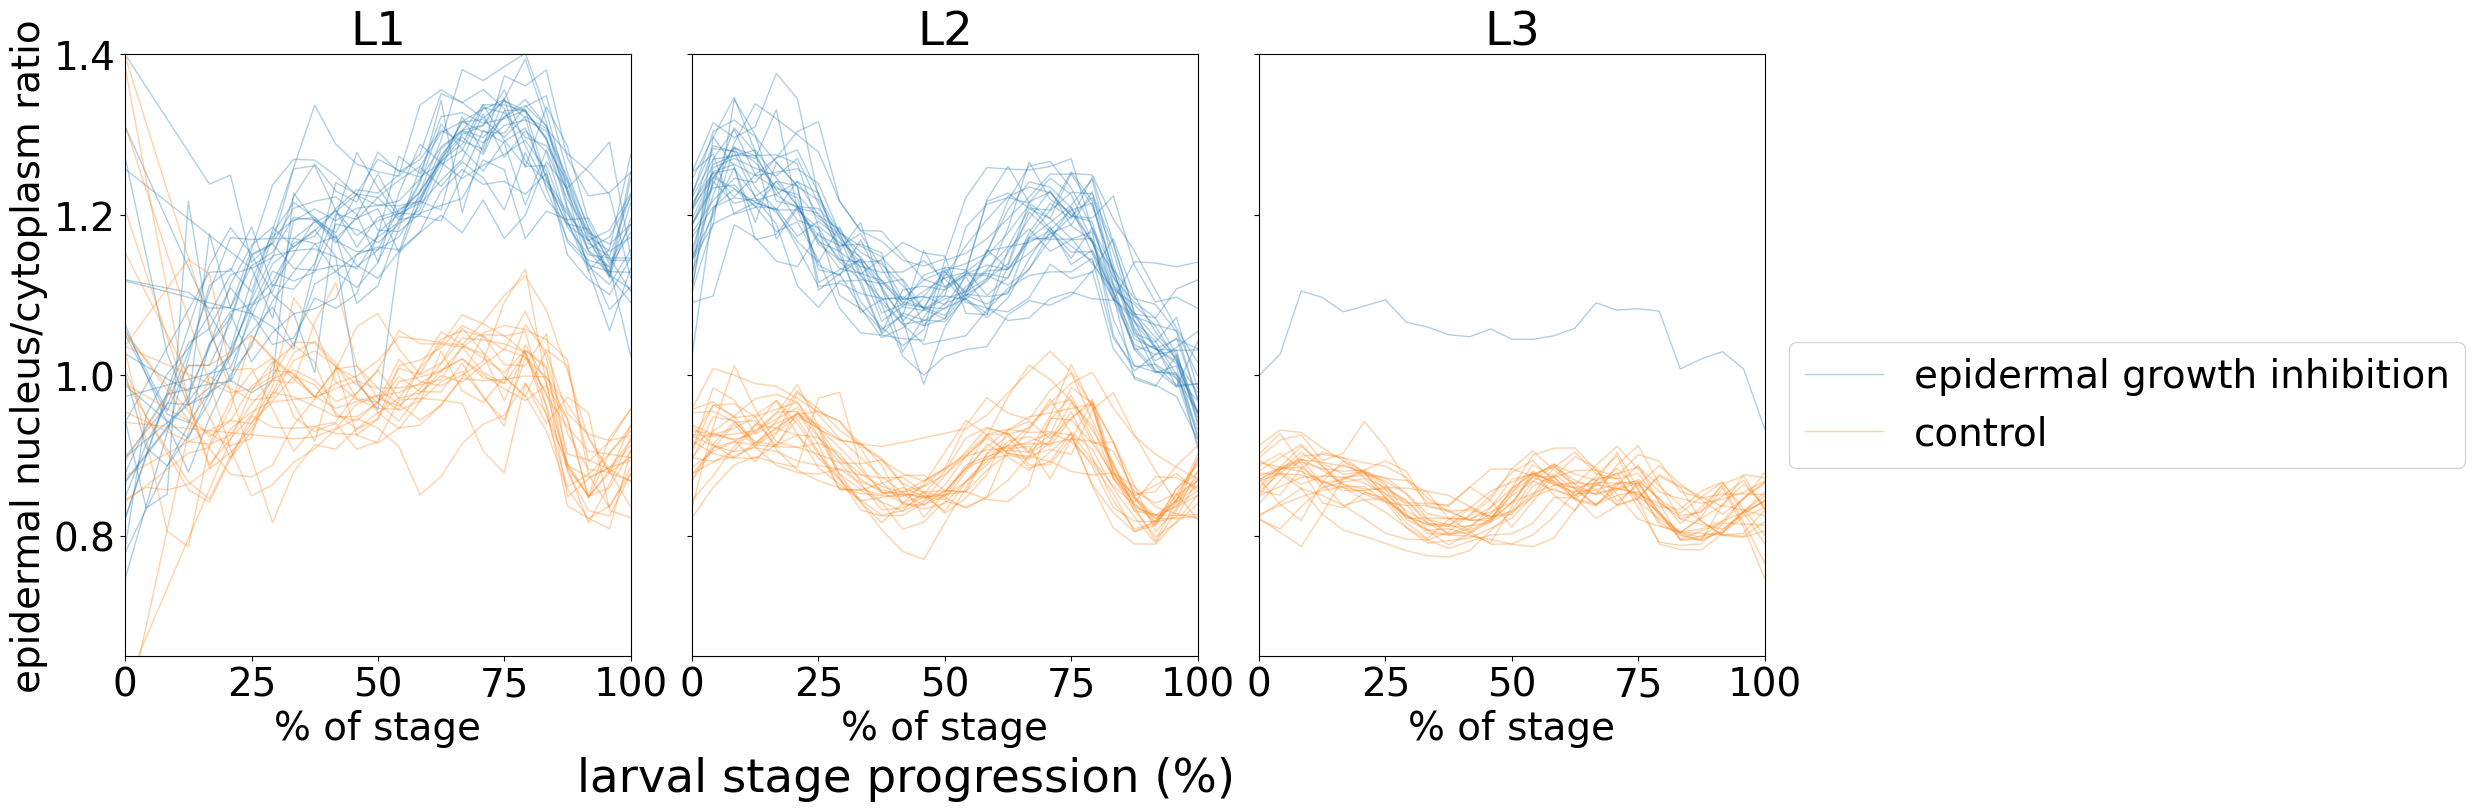

In [126]:
from towbintools.data_analysis import rescale_series

conditions_filemaps = experiment_filemap.partition_by("condition_id", maintain_order=True)
column_to_plot = "NucleusCytoplasmRatioMedian_mean_epidermis"
n_points = 25
limit_per_condition = [3, 3]
ylim = (0.65, 1.4)

n_stages = max(limit_per_condition)
stage_names = ["L1", "L2", "L3", "L4"][:n_stages]

fig, axes = plt.subplots(
    1, n_stages, sharey=True, figsize=(6 * n_stages, 8), squeeze=False
)
axes = axes.ravel()

x = np.linspace(0, 100, n_points)
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
legend_handles = {}

for i, condition_filemap in enumerate(conditions_filemaps):
    condition_id = condition_filemap["condition_id"][0]
    color = colors[i % len(colors)]
    label = new_descriptions[condition_id]

    series_values = separate_column_by_point(condition_filemap, column_to_plot)
    (time, experiment_time, ecdysis_index, ecdysis,
     ecdysis_experiment_time) = _get_time_ecdysis_and_durations(condition_filemap)

    keep = ~np.isnan(series_values).all(axis=1)
    series_values = series_values[keep]
    experiment_time = experiment_time[keep]
    ecdysis_index = ecdysis_index[keep]

    qc = np.full(series_values.shape, "worm", dtype=object)
    _, rescaled = rescale_series(
        series_values, experiment_time, ecdysis_index, qc, n_points=n_points
    )  # (n_worms, 4, n_points)

    n_stages_condition = min(limit_per_condition[i], rescaled.shape[1], n_stages)

    for stage in range(n_stages_condition):
        y = rescaled[:, stage, :]                      # (n_worms, n_points)
        lines = axes[stage].plot(x, y.T, color=color, alpha=0.35, lw=1, label=label)

for stage, ax in enumerate(axes):
    ax.set_title(stage_names[stage])
    ax.set_xlabel("% of stage")
    ax.set_ylim(*ylim)

for stage, ax in enumerate(axes):
    ax.set_title(stage_names[stage])
    ax.set_ylim(ylim)
    ax.set_xlim(0, 100)

axes[0].set_ylabel('epidermal nucleus/cytoplasm ratio')

# gather unique handles/labels across all subplots
handles, labels = [], []
for ax in axes:
    h, l = ax.get_legend_handles_labels()
    for hi, li in zip(h, l):
        if li not in labels:
            handles.append(hi)
            labels.append(li)


fig.legend(handles, labels, loc='center left', bbox_to_anchor=(0.98, 0.5))

fig.supxlabel('larval stage progression (%)')
fig.savefig(
    os.path.join(output_dir, f"epidermal_{column_to_plot}_rescaled.pdf"),
    bbox_inches='tight'
)
plt.show()
plt.show()

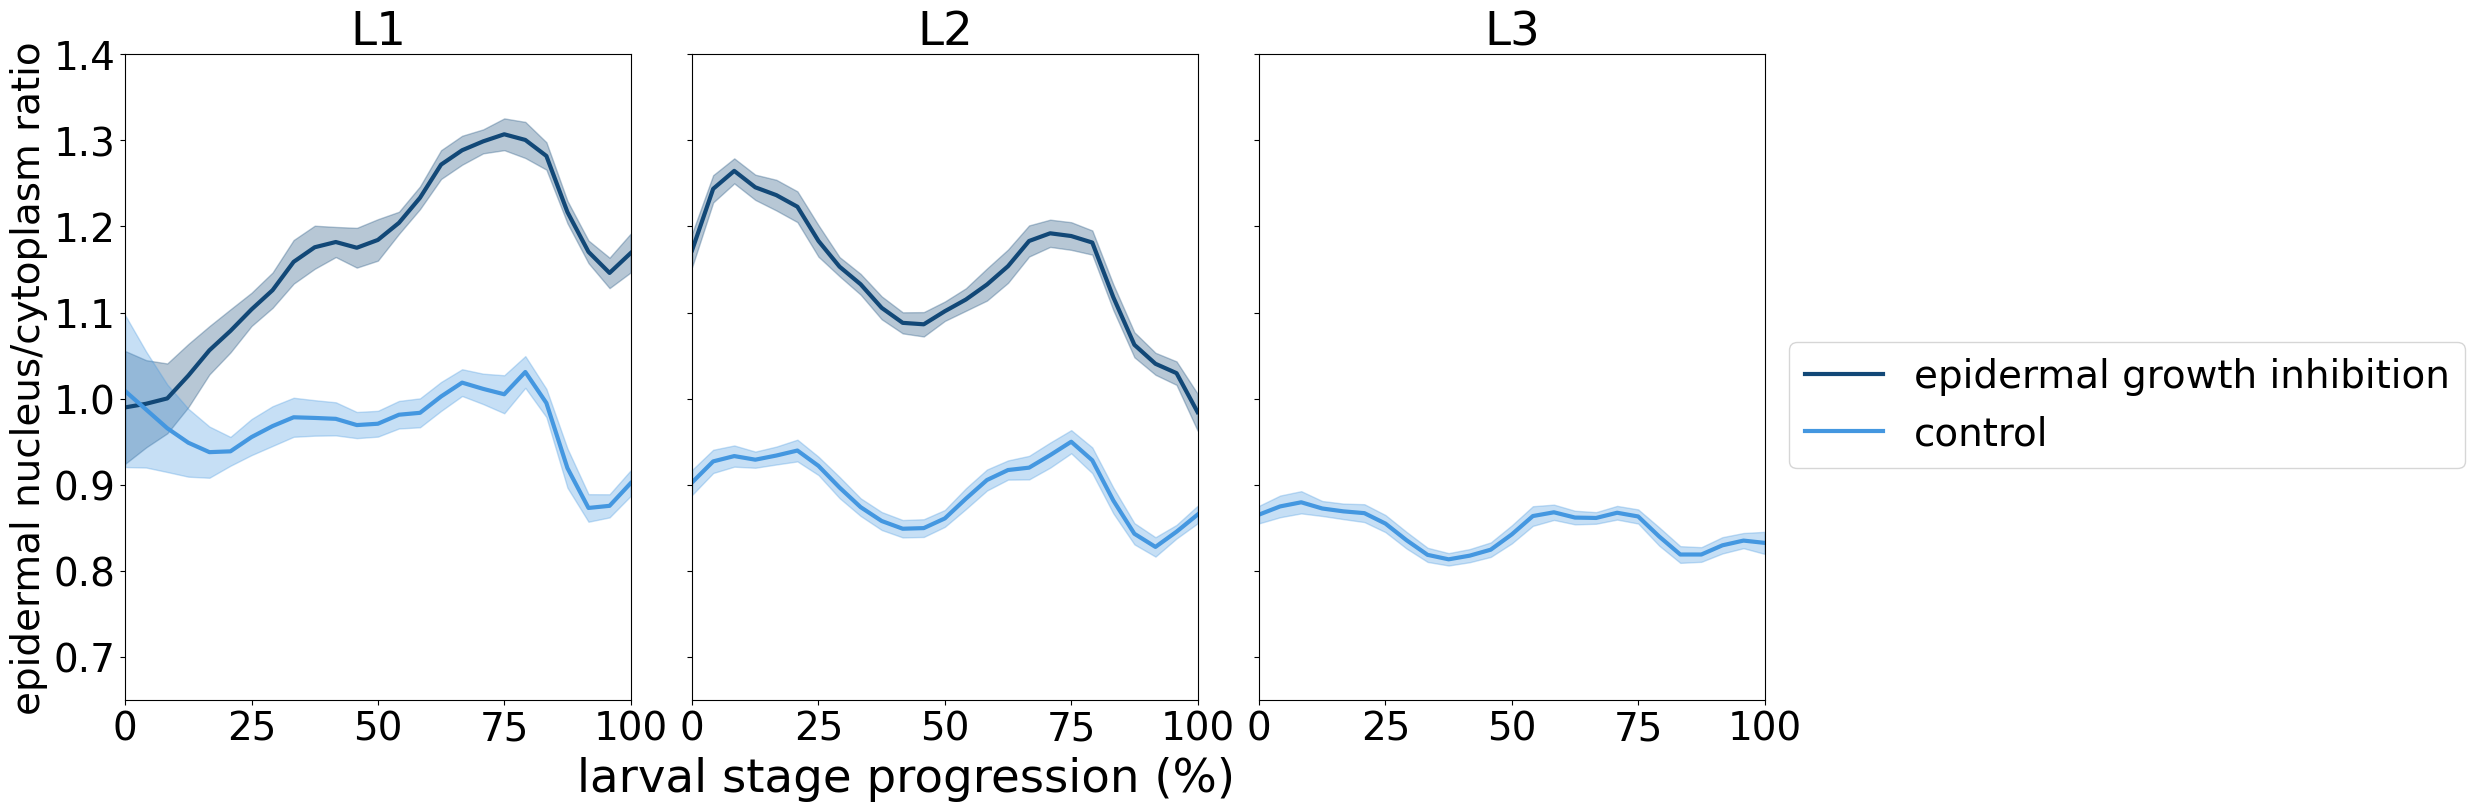

In [114]:
from towbintools.data_analysis import rescale_series
import bottleneck as bn

conditions_filemaps = experiment_filemap.partition_by("condition_id", maintain_order=True)
column_to_plot = "NucleusCytoplasmRatioMedian_mean_epidermis"
n_points = 25
limit_per_condition = [2, 3]

ylim = (0.65, 1.4)

n_stages = max(limit_per_condition)
stage_names = ["L1", "L2", "L3", "L4"][:n_stages]

fig, axes = plt.subplots(1, n_stages, sharey=True, figsize=(6 * n_stages, 8))
if n_stages == 1:
    axes = [axes]

x = np.linspace(0, 100, n_points)

for i, condition_filemap in enumerate(conditions_filemaps):
    condition_id = condition_filemap["condition_id"][0]
    description = condition_filemap["description"][0]
    series_values = separate_column_by_point(condition_filemap, column_to_plot)

    time, experiment_time, ecdysis_index, ecdysis, ecdysis_experiment_time = _get_time_ecdysis_and_durations(condition_filemap)
    all_nan_series = np.isnan(series_values).all(axis=1)
    series_values = series_values[~all_nan_series]
    experiment_time = experiment_time[~all_nan_series]
    ecdysis_index = ecdysis_index[~all_nan_series]
    qc = np.full_like(series_values, "worm", dtype=object)
    _, rescaled_series = rescale_series(
        series_values, experiment_time, ecdysis_index, qc, n_points=n_points
    )  # shape (n_worms, 4, n_points)

    rescaled_series = rescaled_series.reshape(rescaled_series.shape[0], -1)
    n_stages_condition = limit_per_condition[i]
    rescaled_series = rescaled_series[:, 0:n_points * n_stages_condition]

    mean_series = bn.nanmean(rescaled_series, axis=0)
    std_series = bn.nanstd(rescaled_series, axis=0)
    ste_series = std_series / np.sqrt(np.sum(~np.isnan(rescaled_series), axis=0))

    for stage in range(n_stages_condition):
        sl = slice(stage * n_points, (stage + 1) * n_points)
        ax = axes[stage]
        mean_stage = mean_series[sl]
        ste_stage = ste_series[sl]
        ax.plot(x, mean_stage, label=new_descriptions[condition_id], color=condition_id_to_color[condition_id])
        ax.fill_between(
            x,
            mean_stage - 1.96 * ste_stage,
            mean_stage + 1.96 * ste_stage,
            alpha=0.3,
            color=condition_id_to_color[condition_id]
        )

for stage, ax in enumerate(axes):
    ax.set_title(stage_names[stage])
    ax.set_ylim(ylim)
    ax.set_xlim(0, 100)

axes[0].set_ylabel('epidermal nucleus/cytoplasm ratio')

# gather unique handles/labels across all subplots
handles, labels = [], []
for ax in axes:
    h, l = ax.get_legend_handles_labels()
    for hi, li in zip(h, l):
        if li not in labels:
            handles.append(hi)
            labels.append(li)


fig.legend(handles, labels, loc='center left', bbox_to_anchor=(0.98, 0.5))

fig.supxlabel('larval stage progression (%)')
fig.savefig(
    os.path.join(output_dir, f"epidermal_{column_to_plot}_rescaled.pdf"),
    bbox_inches='tight'
)
plt.show()
plt.show()

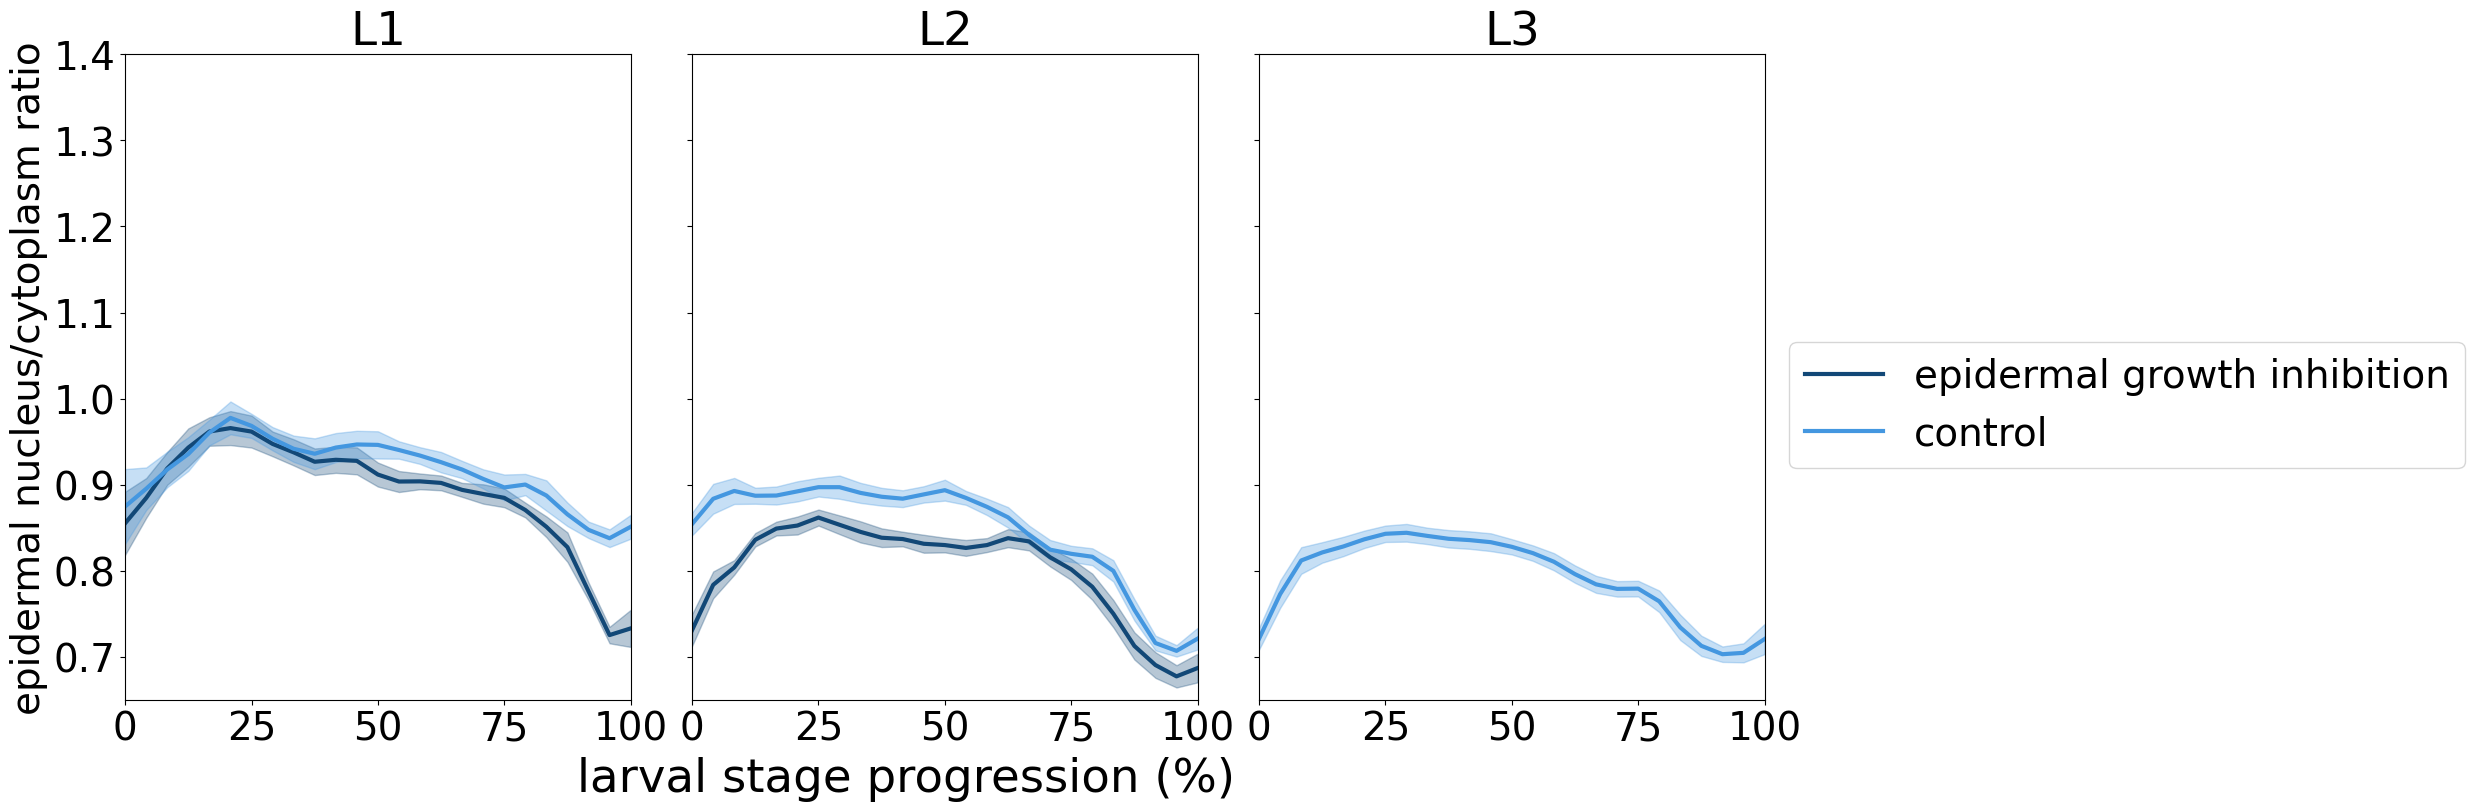

In [115]:
from towbintools.data_analysis import rescale_series
import bottleneck as bn

conditions_filemaps = experiment_filemap.partition_by("condition_id", maintain_order=True)
column_to_plot = "NucleusCytoplasmRatioMedian_mean_intestine"
n_points = 25
limit_per_condition = [2, 3]

n_stages = max(limit_per_condition)
stage_names = ["L1", "L2", "L3", "L4"][:n_stages]

fig, axes = plt.subplots(1, n_stages, sharey=True, figsize=(6 * n_stages, 8))
if n_stages == 1:
    axes = [axes]

x = np.linspace(0, 100, n_points)

for i, condition_filemap in enumerate(conditions_filemaps):
    condition_id = condition_filemap["condition_id"][0]
    description = condition_filemap["description"][0]
    series_values = separate_column_by_point(condition_filemap, column_to_plot)

    time, experiment_time, ecdysis_index, ecdysis, ecdysis_experiment_time = _get_time_ecdysis_and_durations(condition_filemap)
    all_nan_series = np.isnan(series_values).all(axis=1)
    series_values = series_values[~all_nan_series]
    experiment_time = experiment_time[~all_nan_series]
    ecdysis_index = ecdysis_index[~all_nan_series]
    qc = np.full_like(series_values, "worm", dtype=object)
    _, rescaled_series = rescale_series(
        series_values, experiment_time, ecdysis_index, qc, n_points=n_points
    )  # shape (n_worms, 4, n_points)

    rescaled_series = rescaled_series.reshape(rescaled_series.shape[0], -1)
    n_stages_condition = limit_per_condition[i]
    rescaled_series = rescaled_series[:, 0:n_points * n_stages_condition]

    mean_series = bn.nanmean(rescaled_series, axis=0)
    std_series = bn.nanstd(rescaled_series, axis=0)
    ste_series = std_series / np.sqrt(np.sum(~np.isnan(rescaled_series), axis=0))

    for stage in range(n_stages_condition):
        sl = slice(stage * n_points, (stage + 1) * n_points)
        ax = axes[stage]
        mean_stage = mean_series[sl]
        ste_stage = ste_series[sl]
        ax.plot(x, mean_stage, label=new_descriptions[condition_id], color=condition_id_to_color[condition_id])
        ax.fill_between(
            x,
            mean_stage - 1.96 * ste_stage,
            mean_stage + 1.96 * ste_stage,
            alpha=0.3,
            color=condition_id_to_color[condition_id]
        )

for stage, ax in enumerate(axes):
    ax.set_title(stage_names[stage])
    ax.set_ylim(ylim)
    ax.set_xlim(0, 100)

axes[0].set_ylabel('epidermal nucleus/cytoplasm ratio')

# gather unique handles/labels across all subplots
handles, labels = [], []
for ax in axes:
    h, l = ax.get_legend_handles_labels()
    for hi, li in zip(h, l):
        if li not in labels:
            handles.append(hi)
            labels.append(li)


fig.legend(handles, labels, loc='center left', bbox_to_anchor=(0.98, 0.5))

fig.supxlabel('larval stage progression (%)')
fig.savefig(
    os.path.join(output_dir, f"epidermal_{column_to_plot}_rescaled.pdf"),
    bbox_inches='tight'
)
plt.show()
plt.show()

In [116]:
from towbintools.data_analysis import rescale_series
import bottleneck as bn

conditions_filemaps = experiment_filemap.partition_by("condition_id", maintain_order=True)
column_to_plot = "NucleusCytoplasmRatioMedian_mean_other"
n_points = 25
limit_per_condition = [2, 3]

n_stages = max(limit_per_condition)
stage_names = ["L1", "L2", "L3", "L4"][:n_stages]

fig, axes = plt.subplots(1, n_stages, sharey=True, figsize=(6 * n_stages, 8))
if n_stages == 1:
    axes = [axes]

x = np.linspace(0, 100, n_points)

for i, condition_filemap in enumerate(conditions_filemaps):
    condition_id = condition_filemap["condition_id"][0]
    description = condition_filemap["description"][0]
    series_values = separate_column_by_point(condition_filemap, column_to_plot)

    time, experiment_time, ecdysis_index, ecdysis, ecdysis_experiment_time = _get_time_ecdysis_and_durations(condition_filemap)
    all_nan_series = np.isnan(series_values).all(axis=1)
    series_values = series_values[~all_nan_series]
    experiment_time = experiment_time[~all_nan_series]
    ecdysis_index = ecdysis_index[~all_nan_series]
    qc = np.full_like(series_values, "worm", dtype=object)
    _, rescaled_series = rescale_series(
        series_values, experiment_time, ecdysis_index, qc, n_points=n_points
    )  # shape (n_worms, 4, n_points)

    rescaled_series = rescaled_series.reshape(rescaled_series.shape[0], -1)
    n_stages_condition = limit_per_condition[i]
    rescaled_series = rescaled_series[:, 0:n_points * n_stages_condition]

    mean_series = bn.nanmean(rescaled_series, axis=0)
    std_series = bn.nanstd(rescaled_series, axis=0)
    ste_series = std_series / np.sqrt(np.sum(~np.isnan(rescaled_series), axis=0))

    for stage in range(n_stages_condition):
        sl = slice(stage * n_points, (stage + 1) * n_points)
        ax = axes[stage]
        mean_stage = mean_series[sl]
        ste_stage = ste_series[sl]
        ax.plot(x, mean_stage, label=new_descriptions[condition_id], color=condition_id_to_color[condition_id])
        ax.fill_between(
            x,
            mean_stage - 1.96 * ste_stage,
            mean_stage + 1.96 * ste_stage,
            alpha=0.3,
            color=condition_id_to_color[condition_id]
        )

for stage, ax in enumerate(axes):
    ax.set_title(stage_names[stage])
    ax.set_ylim(ylim)
    ax.set_xlim(0, 100)

axes[0].set_ylabel('epidermal nucleus/cytoplasm ratio')

# gather unique handles/labels across all subplots
handles, labels = [], []
for ax in axes:
    h, l = ax.get_legend_handles_labels()
    for hi, li in zip(h, l):
        if li not in labels:
            handles.append(hi)
            labels.append(li)


fig.legend(handles, labels, loc='center left', bbox_to_anchor=(0.98, 0.5))

fig.supxlabel('larval stage progression (%)')
fig.savefig(
    os.path.join(output_dir, f"epidermal_{column_to_plot}_rescaled.pdf"),
    bbox_inches='tight'
)
plt.show()
plt.show()

KeyboardInterrupt: 

# Find examples

In [ ]:
experiment_filemap = experiment_filemap.filter(pl.col("M1").is_not_null())
experiment_filemap = experiment_filemap.filter((pl.col("Time") < pl.col("M1")) & (pl.col("Time") > pl.col("HatchTime")))

# wBT397
filemap = experiment_filemap.filter(pl.col("strain") == "wBT397")
filemap = filemap.filter(pl.col("ch1_cellpose_measurements_NucleusCytoplasmRatioMedian").is_not_null())
filemap = filemap.sort("ch1_cellpose_measurements_NucleusCytoplasmRatioMedian", descending=True).head(10)

print("###### wBT397 - top 10 highest nucleus/cytoplasm ratio before M1 ###")
stacks = filemap.select(pl.col("raw_stacks")).to_numpy().flatten().tolist()
time_relative_to_m1 = filemap.select(pl.col("ExperimentTimeHoursRelativeToM1")).to_numpy().flatten().tolist()
for stack in stacks:
    print(stack, time_relative_to_m1[stacks.index(stack)])

experiment_filemap = experiment_filemap.filter(pl.col("M1").is_not_null())
experiment_filemap = experiment_filemap.filter((pl.col("Time") < pl.col("M1")) & (pl.col("Time") > pl.col("HatchTime")))

# wBT405
filemap = experiment_filemap.filter(pl.col("strain") == "wBT405")
filemap = filemap.filter(pl.col("ch1_cellpose_measurements_NucleusCytoplasmRatioMedian").is_not_null())
filemap = filemap.sort("ch1_cellpose_measurements_NucleusCytoplasmRatioMedian", descending=True).head(10)

print("###### wBT405 - top 10 highest nucleus/cytoplasm ratio before M1 ###")
stacks = filemap.select(pl.col("raw_stacks")).to_numpy().flatten().tolist()
time_relative_to_m1 = filemap.select(pl.col("ExperimentTimeHoursRelativeToM1")).to_numpy().flatten().tolist()
for stack in stacks:
    print(stack, time_relative_to_m1[stacks.index(stack)])

ColumnNotFoundError: unable to find column "ch1_cellpose_measurements_NucleusCytoplasmRatioMedian"; valid columns: ["Time", "Point", "raw", "ExperimentTime", "analysis/ch1_seg", "ch1_seg_area", "placeholder_worm_type", "HatchTime", "M1", "M2", "M3", "M4", "Ignore", "raw_stacks", "ch2_seg_cellpose", "ch1_cellpose_final_measurements", "ExperimentTimeHours", "auxin_concentration", "strain", "description", "condition_id", "Size_mean_other", "Size_std_other", "MeanIntensityNucleus_mean_other", "MeanIntensityNucleus_std_other", "MedianIntensityNucleus_mean_other", "MedianIntensityNucleus_std_other", "MeanIntensityCytoplasm_mean_other", "MeanIntensityCytoplasm_std_other", "MedianIntensityCytoplasm_mean_other", "MedianIntensityCytoplasm_std_other", "NucleusCytoplasmRatioMean_mean_other", "NucleusCytoplasmRatioMean_std_other", "NucleusCytoplasmRatioMedian_mean_other", "NucleusCytoplasmRatioMedian_std_other", "Size_mean_epidermis", "Size_std_epidermis", "MeanIntensityNucleus_mean_epidermis", "Me

In [ ]:
from towbintools.foundation.image_handling import read_tiff_file
from microfilm import microplot
# 397 high activity example
stack_path = "/mnt/towbin.data/shared/spsalmon/20251023_115945_091_ZIVA_60x_397_405_yap_dynamics/raw_stacks/Time00042_Point0022_ChannelDIA,DIA_Seq3404.ome.tiff"
stack = read_tiff_file(stack_path)
plane_of_interest = 9
plane = stack[plane_of_interest]

plane = plane[:, 100:-100, 100:-100] # crop the borders of the image, as these are often noisy and can have artefacts from the segmentation

# small amount of gaussian blur to reduce noise
from scipy.ndimage import gaussian_filter
plane[0] = gaussian_filter(plane[0], sigma=0.25)
plane[1] = gaussian_filter(plane[1], sigma=0.25)
# get the 1st and 99th percentile of each channel
ch1_percentiles = np.percentile(plane[0], [0.05, 99.9])
ch2_percentiles = np.percentile(plane[1], [0.05, 99.9])

microim = microplot.microshow(images=plane[0], dpi=600, proj_type="max", limits = (ch1_percentiles), cmaps=['green'], scalebar_unit_per_pix = 0.65/3, scalebar_size_in_units=50, unit = 'um')
microim.savefig(os.path.join(output_dir, "wBT397_high_nuc_cyto_ratio_example_gfp.png"), dpi=600, bbox_inches='tight', pad_inches=0)

microim = microplot.microshow(images=plane[1], dpi=600, proj_type="max", limits = (ch2_percentiles), cmaps=['red'], scalebar_unit_per_pix = 0.65/3, scalebar_size_in_units=50, unit = 'um')
microim.savefig(os.path.join(output_dir, "wBT397_high_nuc_cyto_ratio_example_mcherry.png"), dpi=600, bbox_inches='tight', pad_inches=0)

microim = microplot.microshow(images=plane, dpi=600, proj_type="max", limits = (ch1_percentiles, ch2_percentiles), cmaps=['green', 'red'], scalebar_unit_per_pix = 0.65/3, scalebar_size_in_units=50, unit = 'um')
microim.savefig(os.path.join(output_dir, "wBT397_high_nuc_cyto_ratio_example_combined.png"), dpi=600, bbox_inches='tight', pad_inches=0)

In [ ]:
# 405 high activity example
stack_path = "/mnt/towbin.data/shared/spsalmon/20251023_115945_091_ZIVA_60x_397_405_yap_dynamics/raw_stacks/Time00045_Point0056_ChannelDIA,DIA_Seq3712.ome.tiff"
stack = read_tiff_file(stack_path)
plane_of_interest = 8
plane = stack[plane_of_interest]

plane = plane[:, 100:-100, 100:-100] # crop the borders of the image, as these are often noisy and can have artefacts from the segmentation

# small amount of gaussian blur to reduce noise
plane[0] = gaussian_filter(plane[0], sigma=0.25)
plane[1] = gaussian_filter(plane[1], sigma=0.25)


microim = microplot.microshow(images=plane[0], dpi=600, proj_type="max", limits = (ch1_percentiles), cmaps=['green'], scalebar_unit_per_pix = 0.65/3, scalebar_size_in_units=50, unit = 'um')
microim.savefig(os.path.join(output_dir, "wBT405_high_nuc_cyto_ratio_example_gfp.png"), dpi=600, bbox_inches='tight', pad_inches=0)

microim = microplot.microshow(images=plane[1], dpi=600, proj_type="max", limits = (ch2_percentiles), cmaps=['red'], scalebar_unit_per_pix = 0.65/3, scalebar_size_in_units=50, unit = 'um')
microim.savefig(os.path.join(output_dir, "wBT405_high_nuc_cyto_ratio_example_mcherry.png"), dpi=600, bbox_inches='tight', pad_inches=0)

microim = microplot.microshow(images=plane, dpi=600, proj_type="sum", limits = (ch1_percentiles, ch2_percentiles), cmaps=['green', 'red'], scalebar_unit_per_pix = 0.65/3, scalebar_size_in_units=50, unit = 'um')
microim.savefig(os.path.join(output_dir, "wBT405_high_nuc_cyto_ratio_example_combined.png"), dpi=600, bbox_inches='tight', pad_inches=0)

In [ ]:
experiment_filemap = experiment_filemap.filter(pl.col("M1").is_not_null())
experiment_filemap = experiment_filemap.filter((pl.col("Time") < pl.col("M1")) & (pl.col("Time") > pl.col("HatchTime")))
# experiment_filemap = experiment_filemap.filter(pl.col('ExperimentTimeHoursRelativeToM1') > -8)

# wBT397
filemap = experiment_filemap.filter(pl.col("strain") == "wBT397")
filemap = filemap.filter(pl.col('ExperimentTimeHoursRelativeToM1') > -8)
filemap = filemap.filter(pl.col("ch1_cellpose_measurements_NucleusCytoplasmRatioMedian").is_not_null())
filemap = filemap.filter(pl.col('Point') == 22) # only keep the point with the lowest nucleus/cytoplasm ratio
filemap = filemap.sort("ch1_cellpose_measurements_NucleusCytoplasmRatioMedian", descending=False).head(10)


print("###### wBT397 - top 10 lowest nucleus/cytoplasm ratio before M1 ###")
stacks = filemap.select(pl.col("raw_stacks")).to_numpy().flatten().tolist()
time_relative_to_m1 = filemap.select(pl.col("ExperimentTimeHoursRelativeToM1")).to_numpy().flatten().tolist()
for stack in stacks:
    print(stack, time_relative_to_m1[stacks.index(stack)])

experiment_filemap = experiment_filemap.filter(pl.col("M1").is_not_null())
experiment_filemap = experiment_filemap.filter((pl.col("Time") < pl.col("M1")) & (pl.col("Time") > pl.col("HatchTime")))

# wBT405
filemap = experiment_filemap.filter(pl.col("strain") == "wBT405")
filemap = filemap.filter(pl.col('ExperimentTimeHoursRelativeToM1') > -8)
filemap = filemap.filter(pl.col("ch1_cellpose_measurements_NucleusCytoplasmRatioMedian").is_not_null())
filemap = filemap.filter(pl.col('Point') == 56) # only keep the point with the lowest nucleus/cytoplasm ratio

filemap = filemap.sort("ch1_cellpose_measurements_NucleusCytoplasmRatioMedian", descending=False).head(10)

print("###### wBT405 - top 10 lowest nucleus/cytoplasm ratio before M1 ###")
stacks = filemap.select(pl.col("raw_stacks")).to_numpy().flatten().tolist()
time_relative_to_m1 = filemap.select(pl.col("ExperimentTimeHoursRelativeToM1")).to_numpy().flatten().tolist()
for stack in stacks:
    print(stack, time_relative_to_m1[stacks.index(stack)])

In [ ]:
# 397 low activity example
stack_path = "/mnt/towbin.data/shared/spsalmon/20251023_115945_091_ZIVA_60x_397_405_yap_dynamics/raw_stacks/Time00057_Point0022_ChannelDIA,DIA_Seq4604.ome.tiff"
stack = read_tiff_file(stack_path)
plane_of_interest = 6
plane = stack[plane_of_interest]

plane = plane[:, 100:-100, 100:-100] # crop the borders of the image, as these are often noisy and can have artefacts from the segmentation

# small amount of gaussian blur to reduce noise
plane[0] = gaussian_filter(plane[0], sigma=0.25)
plane[1] = gaussian_filter(plane[1], sigma=0.25)


microim = microplot.microshow(images=plane[0], dpi=600, proj_type="max", limits = (ch1_percentiles), cmaps=['green'], scalebar_unit_per_pix = 0.65/3, scalebar_size_in_units=50, unit = 'um')
microim.savefig(os.path.join(output_dir, "wBT397_low_nuc_cyto_ratio_example_gfp.png"), dpi=600, bbox_inches='tight', pad_inches=0)

microim = microplot.microshow(images=plane[1], dpi=600, proj_type="max", limits = (ch2_percentiles), cmaps=['red'], scalebar_unit_per_pix = 0.65/3, scalebar_size_in_units=50, unit = 'um')
microim.savefig(os.path.join(output_dir, "wBT397_low_nuc_cyto_ratio_example_mcherry.png"), dpi=600, bbox_inches='tight', pad_inches=0)

microim = microplot.microshow(images=plane, dpi=600, proj_type="sum", limits = (ch1_percentiles, ch2_percentiles), cmaps=['green', 'red'], scalebar_unit_per_pix = 0.65/3, scalebar_size_in_units=50, unit = 'um')
microim.savefig(os.path.join(output_dir, "wBT397_low_nuc_cyto_ratio_example.png"), dpi=600, bbox_inches='tight', pad_inches=0)

In [ ]:
# 405 low activity example
stack_path = "/mnt/towbin.data/shared/spsalmon/20251023_115945_091_ZIVA_60x_397_405_yap_dynamics/raw_stacks/Time00060_Point0056_ChannelDIA,DIA_Seq4912.ome.tiff"
stack = read_tiff_file(stack_path)
plane_of_interest = 9
plane = stack[plane_of_interest]

plane = plane[:, 100:-100, 100:-100] # crop the borders of the image, as these are often noisy and can have artefacts from the segmentation

plane[0] = gaussian_filter(plane[0], sigma=0.25)
plane[1] = gaussian_filter(plane[1], sigma=0.25)


microim = microplot.microshow(images=plane[0], dpi=600, proj_type="max", limits = (ch1_percentiles), cmaps=['green'], scalebar_unit_per_pix = 0.65/3, scalebar_size_in_units=50, unit = 'um')
microim.savefig(os.path.join(output_dir, "wBT405_low_nuc_cyto_ratio_example_gfp.png"), dpi=600, bbox_inches='tight', pad_inches=0)

microim = microplot.microshow(images=plane[1], dpi=600, proj_type="max", limits = (ch2_percentiles), cmaps=['red'], scalebar_unit_per_pix = 0.65/3, scalebar_size_in_units=50, unit = 'um')
microim.savefig(os.path.join(output_dir, "wBT405_low_nuc_cyto_ratio_example_mcherry.png"), dpi=600, bbox_inches='tight', pad_inches=0)

microim = microplot.microshow(images=plane, dpi=600, proj_type="sum", limits = (ch1_percentiles, ch2_percentiles), cmaps=['green', 'red'], scalebar_unit_per_pix = 0.65/3, scalebar_size_in_units=50, unit = 'um')
microim.savefig(os.path.join(output_dir, "wBT405_low_nuc_cyto_ratio_example.png"), dpi=600, bbox_inches='tight', pad_inches=0)

# Non epidermal binned plots

In [ ]:
experiment_filemap_path = os.path.join(experiment_dir, "analysis", "report", "analysis_filemap_annotated.csv")
experiment_filemap = read_filemap(experiment_filemap_path)
experiment_filemap = experiment_filemap.join(stacks_filemap, on=['Time', 'Point'], how='left')
# remove all the columns with "_at" in their name, as these are not needed for the plotting
experiment_filemap = experiment_filemap.drop([col for col in experiment_filemap.columns if "_at" in col])
# experiment_filemap = experiment_filemap.filter(pl.col("ch1_cellpose_measurements").is_not_null())

experiment_filemap = experiment_filemap.with_columns((pl.col("ExperimentTime") / 3600).alias("ExperimentTimeHours"))

experiment_filemap = get_unclassified_non_epidermal_nuclear_stats(experiment_filemap, channel="ch1", aggregation="per_plane", min_nuclei_per_plane=5)
experiment_filemap = _add_conditions_to_filemap(experiment_filemap, conditions)

In [ ]:
molts = ['M1', 'M2', 'M3', 'M4']
column_to_plot = "ch1_cellpose_measurements_NucleusCytoplasmRatioMedian"


color_palette = plt.get_cmap("tab10")


for molt in molts:
    
    modified_point_filemaps = []
    for point_filemap in experiment_filemap.partition_by("Point", maintain_order=True):
        molt_time = point_filemap[molt][0]

        if molt_time is None:
            modified_point_filemaps.append(point_filemap.with_columns(
                pl.lit(np.nan).alias(f"ExperimentTimeHoursRelativeTo{molt}")
            ))

        else:
            molt_time = float(molt_time)
            point = point_filemap["Point"][0]

            molt_experiment_time = (
                point_filemap
                .filter(pl.col("Time") == molt_time)
                .select("ExperimentTimeHours")
                .item()
            )
            modified_point_filemaps.append(
                point_filemap.with_columns(
                    (pl.col("ExperimentTimeHours") - molt_experiment_time).alias(f"ExperimentTimeHoursRelativeTo{molt}")
                )
            )

    experiment_filemap = pl.concat(modified_point_filemaps).sort(["Point", "Time"])

    filemap_for_plotting = experiment_filemap.filter((pl.col(f"ExperimentTimeHoursRelativeTo{molt}") >= -8) & (pl.col(f"ExperimentTimeHoursRelativeTo{molt}") <= 8))

    filemap_for_plotting = filemap_for_plotting.with_columns(
        (pl.col(f"ExperimentTimeHoursRelativeTo{molt}") // 1).alias(f"ExperimentTimeHoursRelativeTo{molt}Bin")
    )
    # remove all the rows with null values in the column to plot
    filemap_for_plotting = filemap_for_plotting.filter(pl.col(f"ExperimentTimeHoursRelativeTo{molt}Bin").is_not_null())
    filemap_for_plotting = filemap_for_plotting.filter(pl.col(column_to_plot).is_not_null())
    conditions_filemaps = filemap_for_plotting.partition_by("condition_id", maintain_order=True)

    for i, condition_filemap in enumerate(conditions_filemaps):
        condition_id = condition_filemap["condition_id"][0]
        description = condition_filemap["description"][0]
        n_points = condition_filemap.select(pl.col("Point").n_unique()).item()
        mean_values = (
            condition_filemap
            .group_by(f"ExperimentTimeHoursRelativeTo{molt}Bin")
            .agg(pl.mean(column_to_plot).alias(column_to_plot))
            .sort(f"ExperimentTimeHoursRelativeTo{molt}Bin")
        )
        std_values = (
            condition_filemap        
            .group_by(f"ExperimentTimeHoursRelativeTo{molt}Bin")
            .agg(pl.std(column_to_plot).alias(column_to_plot))
            .sort(f"ExperimentTimeHoursRelativeTo{molt}Bin")
        )

        ste_values = std_values.with_columns(
            (pl.col(column_to_plot) / np.sqrt(n_points)).alias("ste")
        )
        plt.plot(mean_values[f"ExperimentTimeHoursRelativeTo{molt}Bin"], mean_values[column_to_plot], color = condition_id_to_color[condition_id], label=f"{description}: n={n_points}")
        plt.fill_between(
            mean_values[f"ExperimentTimeHoursRelativeTo{molt}Bin"],
            mean_values[column_to_plot] - 1.96 * ste_values["ste"],
            mean_values[column_to_plot] + 1.96 * ste_values["ste"],
            alpha=0.3,
            color = condition_id_to_color[condition_id]
        )

    plt.xlabel(f'time (hours relative to {molt})')
    plt.ylabel('average nucleus/cytoplasm ratio')
    plt.legend()
    plt.savefig(os.path.join(output_dir, f"{column_to_plot}_relative_to_{molt}.pdf"))
    plt.show()


# Non epidermal rescaled plots

In [ ]:
from towbintools.data_analysis import rescale_series
import bottleneck as bn

conditions_filemaps = experiment_filemap.partition_by("condition_id", maintain_order=True)
column_to_plot = "ch1_cellpose_measurements_NucleusCytoplasmRatioMedian"
n_points = 25
limit_per_condition = [2, 3]

n_stages = max(limit_per_condition)
stage_names = ["L1", "L2", "L3", "L4"][:n_stages]

fig, axes = plt.subplots(1, n_stages, sharey=True, figsize=(6 * n_stages, 8))
if n_stages == 1:
    axes = [axes]

x = np.linspace(0, 100, n_points)

for i, condition_filemap in enumerate(conditions_filemaps):
    condition_id = condition_filemap["condition_id"][0]
    description = condition_filemap["description"][0]
    series_values = separate_column_by_point(condition_filemap, column_to_plot)

    time, experiment_time, ecdysis_index, ecdysis, ecdysis_experiment_time = _get_time_ecdysis_and_durations(condition_filemap)
    all_nan_series = np.isnan(series_values).all(axis=1)
    series_values = series_values[~all_nan_series]
    experiment_time = experiment_time[~all_nan_series]
    ecdysis_index = ecdysis_index[~all_nan_series]
    qc = np.full_like(series_values, "worm", dtype=object)
    _, rescaled_series = rescale_series(
        series_values, experiment_time, ecdysis_index, qc, n_points=n_points
    )  # shape (n_worms, 4, n_points)

    rescaled_series = rescaled_series.reshape(rescaled_series.shape[0], -1)
    n_stages_condition = limit_per_condition[i]
    rescaled_series = rescaled_series[:, 0:n_points * n_stages_condition]

    mean_series = bn.nanmean(rescaled_series, axis=0)
    std_series = bn.nanstd(rescaled_series, axis=0)
    ste_series = std_series / np.sqrt(np.sum(~np.isnan(rescaled_series), axis=0))

    for stage in range(n_stages_condition):
        sl = slice(stage * n_points, (stage + 1) * n_points)
        ax = axes[stage]
        mean_stage = mean_series[sl]
        ste_stage = ste_series[sl]
        ax.plot(x, mean_stage, label=new_descriptions[condition_id], color=condition_id_to_color[condition_id])
        ax.fill_between(
            x,
            mean_stage - 1.96 * ste_stage,
            mean_stage + 1.96 * ste_stage,
            alpha=0.3,
            color=condition_id_to_color[condition_id]
        )

for stage, ax in enumerate(axes):
    ax.set_title(stage_names[stage])
    ax.set_ylim(ylim)
    ax.set_xlim(0, 100)

axes[0].set_ylabel('epidermal nucleus/cytoplasm ratio')

# gather unique handles/labels across all subplots
handles, labels = [], []
for ax in axes:
    h, l = ax.get_legend_handles_labels()
    for hi, li in zip(h, l):
        if li not in labels:
            handles.append(hi)
            labels.append(li)


fig.legend(handles, labels, loc='center left', bbox_to_anchor=(0.98, 0.5))

fig.supxlabel('larval stage progression (%)')
fig.savefig(
    os.path.join(output_dir, f"non_epidermal_{column_to_plot}_rescaled.pdf"),
    bbox_inches='tight'
)
plt.show()
plt.show()